Predicting House Prices with Linear Regression

Import Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("ggplot")
%matplotlib inline

LOAD DATASETS

In [6]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Housing.csv")

Initial Inspection ✅

In [7]:
df.info

<bound method DataFrame.info of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no

In [8]:
df.describe

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       

In [9]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [10]:
df.tail(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [11]:
df.index

RangeIndex(start=0, stop=545, step=1)

In [12]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [13]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

The dataset contains housing information
such as area, bedrooms, bathrooms, parking, furnishing status, and price. These variables will be used to predict house prices.

Null Value Check ✅

In [14]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total Missing Values

In [15]:
df.isnull().sum().sum()

np.int64(0)

Heatmap

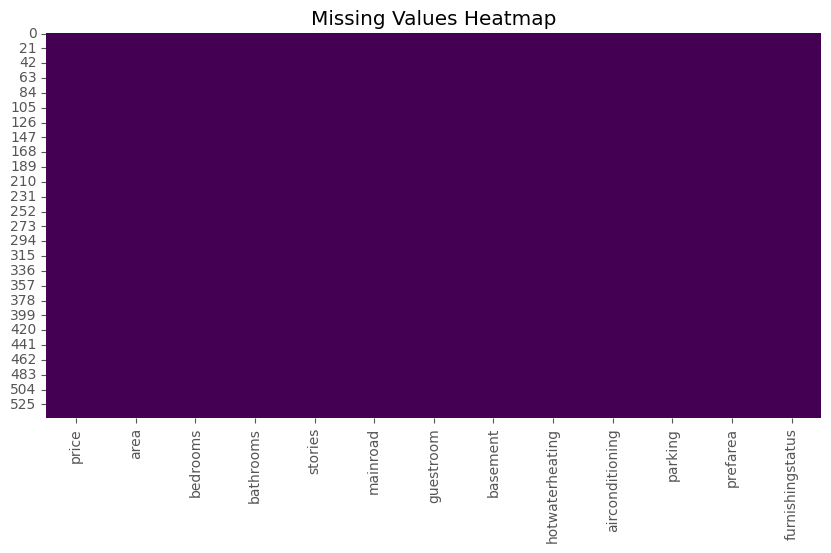

In [16]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),cbar=False,cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

There are no missing values (or only a few).
    If any are present, they will be handled before model training.

Descriptive Statistics ✅


In [18]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


mean

In [19]:
df.mean(numeric_only=True)

price        4.766729e+06
area         5.150541e+03
bedrooms     2.965138e+00
bathrooms    1.286239e+00
stories      1.805505e+00
parking      6.935780e-01
dtype: float64

In [ ]:
Median

In [20]:
df.median(numeric_only=True)

price        4340000.0
area            4600.0
bedrooms           3.0
bathrooms          1.0
stories            2.0
parking            0.0
dtype: float64

mode

In [21]:
df.mode(numeric_only=True)

,price,area,bedrooms,bathrooms,stories,parking
0,3500000,6000.0,3.0,1.0,2.0,0.0
1,4200000,NaN,NaN,NaN,NaN,NaN


Standard Deviation

In [22]:
df.std(numeric_only=True)

price        1.870440e+06
area         2.170141e+03
bedrooms     7.380639e-01
bathrooms    5.024696e-01
stories      8.674925e-01
parking      8.615858e-01
dtype: float64

📝 Markdown
The descriptive statistics indicate a wide variation in house prices and property sizes, suggesting diverse housin

Distribution of Target Variable (Price) ✅

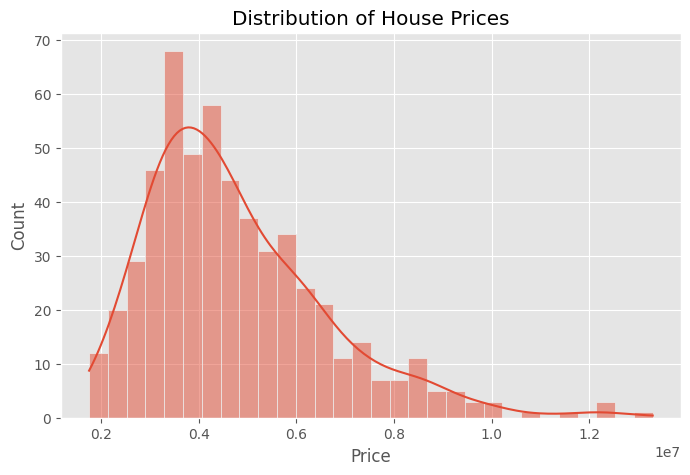

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"],bins=30,kde=True)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

Most houses fall within the mid-price range,
while a smaller number of premium houses create a right-skewed distribution.

Feature Selection Discussion ✅
Selected Features
Area
Bedrooms
Bathrooms
Stories
Main Road
Guest Room
Basement
Air Conditioning
Parking
Preferred Area
Furnishing Status

These variables are selected because they directly influence property value. Larger houses with more bedrooms, bathrooms, parking spaces, and premium amenities generally command higher prices.

Handle Missing Values ✅

Numeric Columns

In [28]:
numeric_columns=df.select_dtypes(include=np.number).columns
df[numeric_columns]=df[numeric_columns].fillna(df[numeric_columns].median())

Categorical Columns

In [29]:
categorical_columns=df.select_dtypes(include="object").columns

for col in categorical_columns:

    df[col]=df[col].fillna(df[col].mode()[0])

One-Hot Encoding ✅

In [30]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [31]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Categorical variables have been converted into numerical variables using One-Hot Encoding so they can be used by the Linear Regression model.

Correlation Heatmap ✅

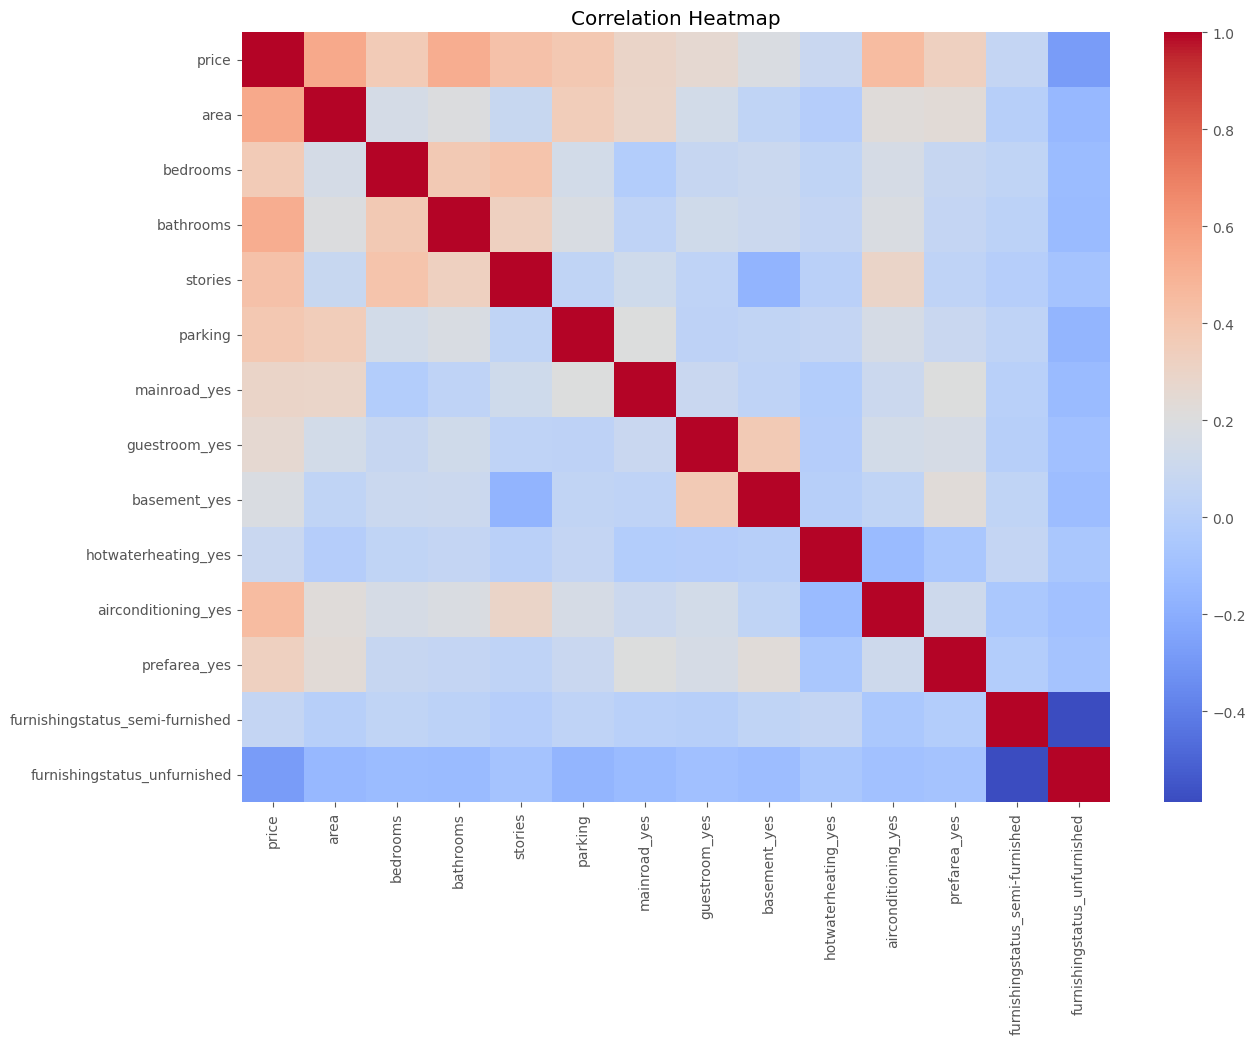

In [32]:
plt.figure(figsize=(14,10))

sns.heatmap(df_encoded.corr(),cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

The heatmap shows that area, bathrooms, and parking have a strong positive correlation with house price.